In [2]:
import pandas as pd 
import os 
import numpy as np 
from glob import glob 
import matplotlib.pyplot as plt
import seaborn as sns


# 정량 

In [43]:
def get_experiment_results(csv_dirs):
    df = pd.DataFrame()
    for cv in csv_dirs:
        cv = os.path.join(cv, 'main.csv')
        temp = pd.read_csv(cv)
        temp['exp_name'] = cv.split('/')[-4].split('-')[0]
        df = pd.concat([df,temp[temp['class_name']=='AA']])
        
    metrics = ['img_level_auroc', 'pix_level_auroc', 'img_level_average_precision', 'pix_level_average_precision']
    df = df.drop(columns=['Unnamed: 0','class_name'])[['exp_name'] + metrics]
    df['average'] = df[metrics].mean(axis=1)
    return df.set_index(df['exp_name']).drop(columns='exp_name')

csv_dirs = [
            '/Volume/VAD/LifeLongerAD_cu121/results/CFGCAD/MVTecAD/sparse26_DST-3_5_with_5_step-Continual_True-online_False/seed_42/results',
            '/Volume/VAD/LifeLongerAD_cu121/results/CFGCAD/MVTecAD/sparse31_DST-3_5_with_5_step-Continual_True-online_False/seed_42/results',
            '/Volume/VAD/LifeLongerAD_cu121/results/CFGCAD/MVTecAD/sparse32_DST-3_5_with_5_step-Continual_True-online_False/seed_42/results'            
            ]


df = get_experiment_results(csv_dirs)
df.round(3)

,img_level_auroc,pix_level_auroc,img_level_average_precision,pix_level_average_precision,average
exp_name,,,,,
sparse26_DST,0.651,0.834,0.808,0.152,0.611
sparse31_DST,0.645,0.831,0.805,0.150,0.608
sparse32_DST,0.657,0.837,0.812,0.159,0.616


Class results dict keys: ['sparse26_DST', 'sparse31_DST', 'sparse32_DST']
Task name map: {'grid': "['grid', 'carpet', 'cable']", 'leather': "['leather', 'pill', 'hazelnut']", 'metal_nut': "['metal_nut', 'transistor', 'bottle']", 'toothbrush': "['toothbrush', 'capsule', 'screw']", 'zipper': "['zipper', 'wood', 'tile']"}


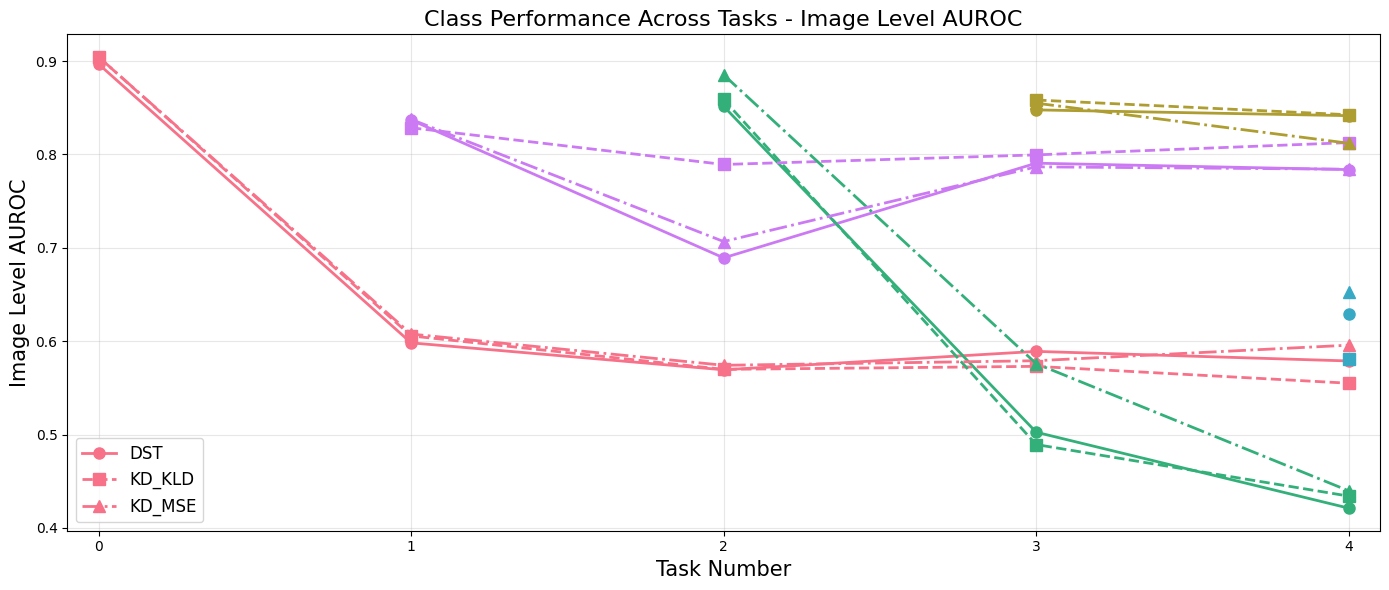

In [57]:
import seaborn as sns
import itertools
import matplotlib.pyplot as plt

def get_class_results_and_task_order(cv):
    cv = os.path.join(cv, 'result_log.csv')
    df = pd.read_csv(cv)

    task_names = df['GT_class_name'].unique()

    class_results = pd.DataFrame()
    for i, tn in enumerate(task_names):
        if i == 0:
            temp_df = df[(df['class_name'] == tn) & (df['last'] == 1)].iloc[0:]
        else:
            temp_df = df[(df['class_name'] == tn) & (df['last'] == 1)].iloc[1:]
        temp_df = temp_df[['class_name', 'GT_class_name', 'img_level_auroc', 'pix_level_auroc', 'img_level_average_precision', 'pix_level_average_precision']]
        metrics = ['img_level_auroc', 'pix_level_auroc', 'img_level_average_precision', 'pix_level_average_precision']
        temp_df['average'] = temp_df[metrics].mean(axis=1)
        class_results = pd.concat([class_results, temp_df])
    
    class_results.round(3).reset_index(drop=True, inplace=True)
    class_results = class_results.loc[class_results.groupby(['class_name', 'GT_class_name'])['average'].idxmax()]
    task_order = {tn: i for i, tn in enumerate(task_names)}

    # Remove rows where class_name's order number is greater than GT_class_name's order number
    class_results['class_task_order'] = class_results['class_name'].map(task_order)
    class_results['gt_task_order'] = class_results['GT_class_name'].map(task_order)
    class_results = class_results[class_results['class_task_order'] <= class_results['gt_task_order']]
    class_results = class_results.drop(columns=['class_task_order', 'gt_task_order'])

    return class_results, task_order

def get_class_results_dict(csv_dirs):
    class_results_dict = {}
    for cv in csv_dirs:
        class_results, task_order = get_class_results_and_task_order(cv)
        class_results_dict[cv.split('/')[-3].split('-')[0]] = class_results
    return class_results_dict, task_order

def visualize_class_results(class_results_dict, task_order, metric='img_level_auroc', exp_name_mapping=None):
    """
    Visualize class results across tasks for multiple experiments.
    
    Parameters:
    - class_results_dict: Dictionary of experiment results
    - task_order: Mapping of task names to their order
    - metric: Metric to visualize ('img_level_auroc', 'pix_level_auroc', 'img_level_average_precision', 'pix_level_average_precision', 'average')
    - exp_name_mapping: Dictionary to map experiment names to display names
    """
    # Metric name mapping for display
    metric_names = {
        'img_level_auroc': 'Image Level AUROC',
        'pix_level_auroc': 'Pixel Level AUROC',
        'img_level_average_precision': 'Image Level Average Precision',
        'pix_level_average_precision': 'Pixel Level Average Precision',
        'average': 'Average Score'
    }
    
    fig, axes = plt.subplots(1, 1, figsize=(14, 6))

    # Use provided mapping or default
    if exp_name_mapping is None:
        exp_name_mapping = {}

    # Automatically generate linestyles and markers based on class_results_dict keys
    linestyle_cycle = itertools.cycle(['-', '--', '-.', ':'])
    marker_cycle = itertools.cycle(['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h', 'H', '+', 'x'])
    linestyles = {key: next(linestyle_cycle) for key in class_results_dict.keys()}
    markers = {key: next(marker_cycle) for key in class_results_dict.keys()}

    # Get unique class names from all experiments
    all_class_names = set()
    for class_results in class_results_dict.values():
        all_class_names.update(class_results['class_name'].unique())
    all_class_names = sorted(list(all_class_names))
    
    colors = sns.color_palette("husl", n_colors=len(all_class_names))
    color_map = {class_name: colors[i] for i, class_name in enumerate(all_class_names)}

    # Track added experiment labels to avoid duplicates
    added_exp_labels = set()

    # Plot data for each experiment
    for key, class_results in class_results_dict.items():
        class_results = class_results.copy()
        class_results['task_number'] = class_results['GT_class_name'].map(task_order)

        for class_name in class_results['class_name'].unique():
            class_data = class_results[class_results['class_name'] == class_name].copy()
            # Sort by task_number to ensure proper order
            class_data = class_data.sort_values('task_number')
            
            # Create simple label for legend (only experiment name, only once per experiment)
            if key not in added_exp_labels:
                label = exp_name_mapping.get(key, key)
                added_exp_labels.add(key)
            else:
                label = None
            
            axes.plot(class_data['task_number'], 
                     class_data[metric],
                     color=color_map[class_name],
                     marker=markers[key],
                     markersize=8,
                     linestyle=linestyles[key],
                     linewidth=2,
                     label=label)

    # Set labels and formatting
    axes.set_xlabel('Task Number', fontsize=15)
    axes.set_ylabel(metric_names.get(metric, metric), fontsize=15)
    axes.set_title(f'Class Performance Across Tasks - {metric_names.get(metric, metric)}', fontsize=16)
    
    # Set x-axis ticks based on task_order values
    task_numbers = sorted(task_order.values())
    axes.set_xticks(task_numbers)
    axes.set_xlim(min(task_numbers) - 0.1, max(task_numbers) + 0.1)
    
    # Add grid for better readability
    axes.grid(True, alpha=0.3)
    
    # Create simple legend
    axes.legend(fontsize=12)
    
    plt.tight_layout()
    plt.show()

# Get class results data


# Print debugging information
def fix_class_name_mapping(class_results_dict):
    """
    Fix the class name mapping issue by creating a mapping from string representation to first element
    
    Args:
        class_results_dict: Dictionary containing class results data
    
    Returns:
        dict: Updated class_results_dict with fixed class name mappings
    """
    print("Class results dict keys:", list(class_results_dict.keys()))
    
    # Fix the class name mapping issue
    if len(class_results_dict) > 0:
        first_key = list(class_results_dict.keys())[0]
        df = class_results_dict[first_key]
        
        # Create task name mapping from string representation to first element
        task_name_map = {}
        for task_name in df['GT_class_name'].unique():
            try:
                parsed_name = eval(task_name)
                if isinstance(parsed_name, list) and len(parsed_name) > 0:
                    task_name_map[parsed_name[0]] = task_name
            except:
                # If eval fails, use the task_name as is
                task_name_map[task_name] = task_name
        
        print("Task name map:", task_name_map)
        
        # Apply mapping to all experiments
        for key in class_results_dict.keys():
            df = class_results_dict[key].copy()
            
            # Map class names if they exist in the mapping
            df['class_name'] = df['class_name'].apply(lambda x: task_name_map.get(x, x))
            df['GT_class_name'] = df['GT_class_name'].apply(lambda x: task_name_map.get(x, x))
            
            class_results_dict[key] = df
    
    return class_results_dict

csv_dirs = [
            '/Volume/VAD/LifeLongerAD_cu121/results/CFGCAD/MVTecAD/sparse26_DST-3_5_with_5_step-Continual_True-online_False/seed_42/results',
            '/Volume/VAD/LifeLongerAD_cu121/results/CFGCAD/MVTecAD/sparse31_DST-3_5_with_5_step-Continual_True-online_False/seed_42/results',
            '/Volume/VAD/LifeLongerAD_cu121/results/CFGCAD/MVTecAD/sparse32_DST-3_5_with_5_step-Continual_True-online_False/seed_42/results'            
            ]

class_results_dict, task_order = get_class_results_dict(csv_dirs)

# Apply the fix
class_results_dict = fix_class_name_mapping(class_results_dict)

# Visualize the results
task_order = {
    "['grid', 'carpet', 'cable']": 0,
    "['zipper', 'wood', 'tile']": 1, 
    "['metal_nut', 'transistor', 'bottle']": 2,
    "['leather', 'pill', 'hazelnut']": 3,
    "['toothbrush', 'capsule', 'screw']": 4
}

# Define experiment name mapping
exp_name_mapping = {
    'sparse26_DST': 'DST',
    'sparse31_DST': 'KD_KLD',
    'sparse32_DST': 'KD_MSE',
}

# You can now specify which metric to visualize
# Available metrics: 'img_level_auroc', 'pix_level_auroc', 'img_level_average_precision', 'pix_level_average_precision', 'average'
visualize_class_results(class_results_dict, task_order, metric='img_level_auroc', exp_name_mapping=exp_name_mapping)

# 학습 추세 

In [2]:
def get_class_results_and_task_order(cv):
    cv = os.path.join(cv, 'result_log.csv')
    df = pd.read_csv(cv)

    task_names = df['GT_class_name'].unique()

    class_results = pd.DataFrame()
    for i, tn in enumerate(task_names):
        if i == 0:
            temp_df = df[(df['class_name'] == tn) & (df['last'] == 1)].iloc[0:]
        else:
            temp_df = df[(df['class_name'] == tn) & (df['last'] == 1)].iloc[1:]
        temp_df = temp_df[['class_name', 'GT_class_name', 'img_level_auroc', 'pix_level_auroc', 'img_level_average_precision', 'pix_level_average_precision']]
        metrics = ['img_level_auroc', 'pix_level_auroc', 'img_level_average_precision', 'pix_level_average_precision']
        temp_df['average'] = temp_df[metrics].mean(axis=1)
        class_results = pd.concat([class_results, temp_df])
    
    class_results.round(3).reset_index(drop=True, inplace=True)
    class_results = class_results.loc[class_results.groupby(['class_name', 'GT_class_name'])['average'].idxmax()]
    task_order = {tn: i for i, tn in enumerate(task_names)}

    # Remove rows where class_name's order number is greater than GT_class_name's order number
    class_results['class_task_order'] = class_results['class_name'].map(task_order)
    class_results['gt_task_order'] = class_results['GT_class_name'].map(task_order)
    class_results = class_results[class_results['class_task_order'] <= class_results['gt_task_order']]
    class_results = class_results.drop(columns=['class_task_order', 'gt_task_order'])

    return class_results, task_order

def get_class_results_dict(csv_dirs):
    class_results_dict = {}
    for cv in csv_dirs:
        class_results, task_order = get_class_results_and_task_order(cv)
        class_results_dict[cv.split('/')[-3].split('-')[0]] = class_results
    return class_results_dict, task_order

csv_dirs = [            
            '/Volume/VAD/LifeLongerAD_cu121/results/CFGCAD/MVTecAD/test_capsule_DST-3_5_with_5_step-Continual_True-online_False/seed_42/results',
            '/Volume/VAD/LifeLongerAD_cu121/results/CFGCAD/MVTecAD/test_toothbrush_DST-3_5_with_5_step-Continual_True-online_False/seed_42/results',
            '/Volume/VAD/LifeLongerAD_cu121/results/CFGCAD/MVTecAD/test_screw_DST-3_5_with_5_step-Continual_True-online_False/seed_42/results'
            ]
task_order = {"['grid', 'carpet', 'cable']": 0,
            "['zipper', 'wood', 'tile']": 1,
            "['metal_nut', 'transistor', 'bottle']": 2,
            "['leather', 'pill', 'hazelnut']": 3,
            "['toothbrush', 'capsule', 'screw']": 4}

# exp_name_mapping = {
#     'sparse26_DST': 'DST',
#     'sparse31_DST': 'KD_KLD',
#     'sparse32_DST': 'KD_MSE',
# }


class_results_dict={}
for cv in csv_dirs:
    cv = os.path.join(cv, 'result_log.csv')
    df = pd.read_csv(cv)

    concat_df = pd.DataFrame()
    for task in task_order:
        temp = df[(df['GT_class_name']==task)&(df['last']==0)].drop(columns=['task','last'])
        concat_df = pd.concat([concat_df, temp])
    concat_df.reset_index(drop=True, inplace=True)
    concat_df.round(3).reset_index(drop=True, inplace=True)    
    
    class_results_dict[cv.split('/')[-4].split('-')[0]] = concat_df
    
fig, axes = plt.subplots(1,1, figsize=(18, 10))

line_styles = ['-', '--', '-.']
markers = ['o', 's', '^']

for i, (key, data) in enumerate(class_results_dict.items()):
    linestyle = line_styles[i % len(line_styles)]
    marker = markers[i % len(markers)]
    
    # Plot each task separately for each experiment
    for j, (task, task_id) in enumerate(task_order.items()):
        task_data = data[data['GT_class_name'] == task]
        if not task_data.empty:
            # For the first experiment, include task name in label
            if i == 0:
                label = f'{task}'
            else:
                label = None  # No label for subsequent experiments to avoid legend duplicates
            
            axes.plot(task_data['epoch'], task_data['img_level_auroc'], 
                     linestyle=linestyle, marker=marker, 
                     color=plt.cm.tab10(j), label=label)

# Create custom legend with task names (colors) and experiment names (markers)
from matplotlib.lines import Line2D

# Task legend (colors)
task_handles = [Line2D([0], [0], color=plt.cm.tab10(j), label=task) 
                for j, task in enumerate(task_order.keys())]

# Experiment legend (markers and line styles) - map experiment names using exp_name_mapping
exp_labels = [exp_name_mapping.get(key, key) for key in class_results_dict.keys()]
exp_handles = [Line2D([0], [0], color='black', linestyle=line_styles[i % len(line_styles)], 
                      marker=markers[i % len(markers)], label=exp_labels[i]) 
               for i in range(len(exp_labels))]

# Add legends
# Combine both legends in one box
all_handles = task_handles + [Line2D([0], [0], color='white', alpha=0)] + exp_handles
all_labels = [handle.get_label() for handle in task_handles] + [''] + [handle.get_label() for handle in exp_handles]

legend = axes.legend(handles=all_handles, labels=all_labels,
                    bbox_to_anchor=(0.7, 0.35), loc='upper left',
                    title='Tasks & Experiments')


axes.set_title('img_level_auroc by epoch')
axes.set_xlabel('Epoch')
axes.set_ylabel('Image Level AUROC')


plt.show()

NameError: name 'os' is not defined

# Forgetting 

In [ ]:
csv_dirs = [
            '/Volume/VAD/LifeLongerAD_cu121/results/CFGCAD/MVTecAD/sparse26_DST-3_5_with_5_step-Continual_True-online_False/seed_42/results',
            '/Volume/VAD/LifeLongerAD_cu121/results/CFGCAD/MVTecAD/sparse31_DST-3_5_with_5_step-Continual_True-online_False/seed_42/results',
            '/Volume/VAD/LifeLongerAD_cu121/results/CFGCAD/MVTecAD/sparse32_DST-3_5_with_5_step-Continual_True-online_False/seed_42/results'            
            ]

forgetting_df = pd.DataFrame()
for cv in csv_dirs:
    cv = os.path.join(cv, 'forgetting.csv')
    df = pd.read_csv(cv)
    df[df['class_name']=='all']
    temp = df[df['class_name']=='all'][['metric','AF']]
    temp['exp_name'] = cv.split('/')[-4].split('-')[0]
    forgetting_df = pd.concat([forgetting_df, temp])
    
forgetting_df = forgetting_df.pivot(index='exp_name', columns='metric', values='AF')

# 개별 class 별로 

,epoch,class_name,GT_class_name,epoch_time,img_level_auroc,img_level_average_precision,pix_level_auroc,pix_level_average_precision
404,0,"['toothbrush', 'capsule', 'screw']","['toothbrush', 'capsule', 'screw']",0.017,0.420,0.744,0.871,0.034
405,2,"['toothbrush', 'capsule', 'screw']","['toothbrush', 'capsule', 'screw']",0.017,0.418,0.746,0.879,0.036
406,4,"['toothbrush', 'capsule', 'screw']","['toothbrush', 'capsule', 'screw']",0.017,0.446,0.761,0.889,0.039
407,6,"['toothbrush', 'capsule', 'screw']","['toothbrush', 'capsule', 'screw']",0.016,0.465,0.771,0.894,0.042
408,8,"['toothbrush', 'capsule', 'screw']","['toothbrush', 'capsule', 'screw']",0.017,0.485,0.779,0.899,0.045
...,...,...,...,...,...,...,...,...
500,192,"['toothbrush', 'capsule', 'screw']","['toothbrush', 'capsule', 'screw']",0.017,0.643,0.861,0.944,0.174
501,194,"['toothbrush', 'capsule', 'screw']","['toothbrush', 'capsule', 'screw']",0.017,0.647,0.862,0.945,0.175
502,196,"['toothbrush', 'capsule', 'screw']","['toothbrush', 'capsule', 'screw']",0.016,0.650,0.863,0.944,0.174
503,198,"['toothbrush', 'capsule', 'screw']","['toothbrush', 'capsule', 'screw']",0.017,0.653,0.864,0.945,0.178


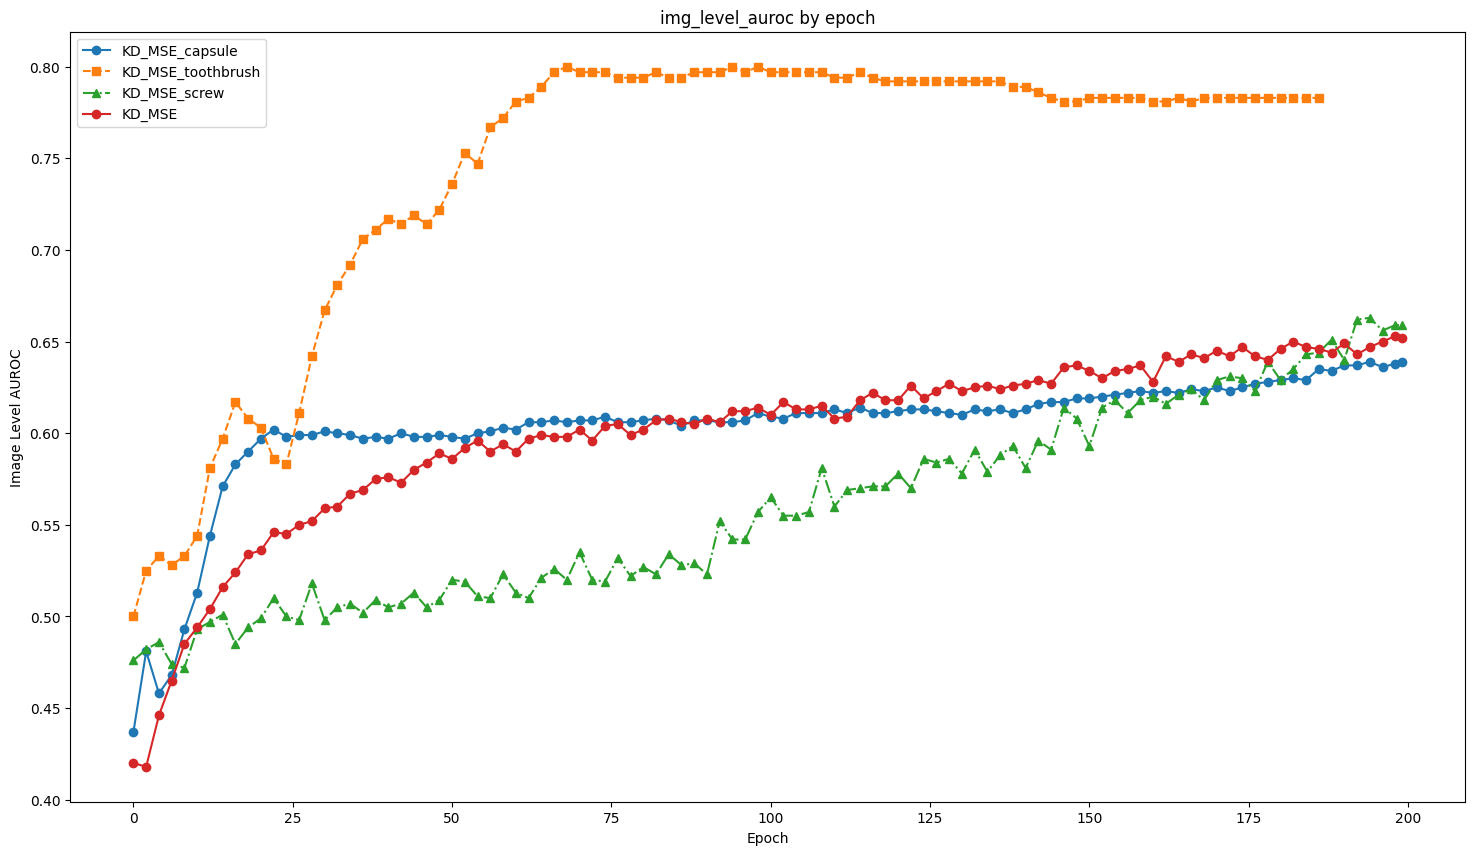

In [6]:
def get_class_results_and_task_order(cv):
    cv = os.path.join(cv, 'result_log.csv')
    df = pd.read_csv(cv)

    task_names = df['GT_class_name'].unique()

    class_results = pd.DataFrame()
    for i, tn in enumerate(task_names):
        if i == 0:
            temp_df = df[(df['class_name'] == tn) & (df['last'] == 1)].iloc[0:]
        else:
            temp_df = df[(df['class_name'] == tn) & (df['last'] == 1)].iloc[1:]
        temp_df = temp_df[['class_name', 'GT_class_name', 'img_level_auroc', 'pix_level_auroc', 'img_level_average_precision', 'pix_level_average_precision']]
        metrics = ['img_level_auroc', 'pix_level_auroc', 'img_level_average_precision', 'pix_level_average_precision']
        temp_df['average'] = temp_df[metrics].mean(axis=1)
        class_results = pd.concat([class_results, temp_df])
    
    class_results = class_results.round(3).reset_index(drop=True)
    class_results = class_results.loc[class_results.groupby(['class_name', 'GT_class_name'])['average'].idxmax()]

    return class_results

def get_class_results_dict(csv_dirs):
    class_results_dict = {}
    for cv in csv_dirs:
        class_results = get_class_results_and_task_order(cv)
        class_results_dict[cv.split('/')[-3].split('-')[0]] = class_results
    return class_results_dict

csv_dirs = [
            '/Volume/VAD/LifeLongerAD_cu121/results/CFGCAD/MVTecAD/test_capsule_DST-3_5_with_5_step-Continual_True-online_False/seed_42/results',
            '/Volume/VAD/LifeLongerAD_cu121/results/CFGCAD/MVTecAD/test_toothbrush_DST-3_5_with_5_step-Continual_True-online_False/seed_42/results',
            '/Volume/VAD/LifeLongerAD_cu121/results/CFGCAD/MVTecAD/test_screw_DST-3_5_with_5_step-Continual_True-online_False/seed_42/results',
            '/Volume/VAD/LifeLongerAD_cu121/results/CFGCAD/MVTecAD/sparse32_DST-3_5_with_5_step-Continual_True-online_False/seed_42/results'          
            ]


exp_name_mapping = {
    'test_capsule_DST': 'KD_MSE_capsule',
    'test_toothbrush_DST': 'KD_MSE_toothbrush',
    'test_screw_DST': 'KD_MSE_screw',
    'sparse32_DST': 'KD_MSE',
}


class_results_dict={}
for cv in csv_dirs:
    cv = os.path.join(cv, 'result_log.csv')
    df = pd.read_csv(cv)
    
    concat_df = df[(df['last']==0)].drop(columns=['task','last'])
    concat_df = concat_df.reset_index(drop=True)
    concat_df = concat_df.round(3)
    
    exp_name = cv.split('/')[-4].split('-')[0]
    
    # sparse32의 경우 특정 클래스만 필터링
    if exp_name == 'sparse32_DST':        
        concat_df = concat_df[concat_df['class_name'].isin(["['toothbrush', 'capsule', 'screw']"])]
        
    # exp_name_mapping 적용
    mapped_name = exp_name_mapping.get(exp_name, exp_name)
    class_results_dict[mapped_name] = concat_df
    
fig, axes = plt.subplots(1,1, figsize=(18, 10))

line_styles = ['-', '--', '-.']
markers = ['o', 's', '^']

for i, (key, data) in enumerate(class_results_dict.items()):
    linestyle = line_styles[i % len(line_styles)]
    marker = markers[i % len(markers)]
    
    axes.plot(data['epoch'], data['img_level_auroc'], 
             linestyle=linestyle, marker=marker, label=key)



axes.legend()
axes.set_title('img_level_auroc by epoch')
axes.set_xlabel('Epoch')
axes.set_ylabel('Image Level AUROC')

plt.show()

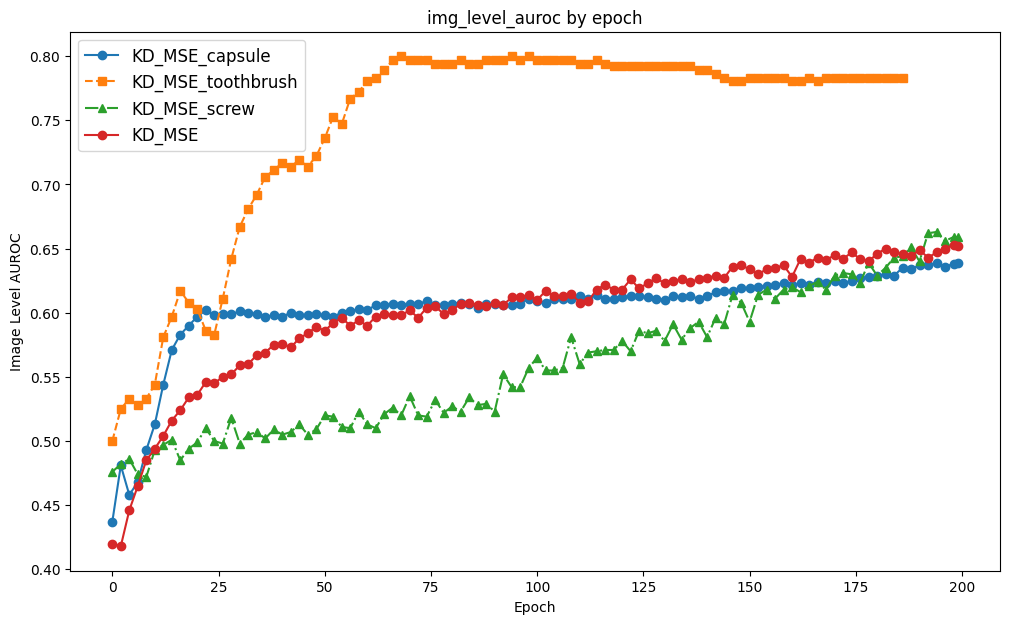

In [17]:
def get_class_results_and_task_order(cv):
    cv = os.path.join(cv, 'result_log.csv')
    df = pd.read_csv(cv)

    task_names = df['GT_class_name'].unique()

    class_results = pd.DataFrame()
    for i, tn in enumerate(task_names):
        if i == 0:
            temp_df = df[(df['class_name'] == tn) & (df['last'] == 1)].iloc[0:]
        else:
            temp_df = df[(df['class_name'] == tn) & (df['last'] == 1)].iloc[1:]
        temp_df = temp_df[['class_name', 'GT_class_name', 'img_level_auroc', 'pix_level_auroc', 'img_level_average_precision', 'pix_level_average_precision']]
        metrics = ['img_level_auroc', 'pix_level_auroc', 'img_level_average_precision', 'pix_level_average_precision']
        temp_df['average'] = temp_df[metrics].mean(axis=1)
        class_results = pd.concat([class_results, temp_df])
    
    class_results = class_results.round(3).reset_index(drop=True)
    class_results = class_results.loc[class_results.groupby(['class_name', 'GT_class_name'])['average'].idxmax()]

    return class_results

def get_class_results_dict(csv_dirs):
    class_results_dict = {}
    for cv in csv_dirs:
        class_results = get_class_results_and_task_order(cv)
        class_results_dict[cv.split('/')[-3].split('-')[0]] = class_results
    return class_results_dict

csv_dirs = [
            '/Volume/VAD/LifeLongerAD_cu121/results/CFGCAD/MVTecAD/test_capsule_DST-3_5_with_5_step-Continual_True-online_False/seed_42/results',
            '/Volume/VAD/LifeLongerAD_cu121/results/CFGCAD/MVTecAD/test_toothbrush_DST-3_5_with_5_step-Continual_True-online_False/seed_42/results',
            '/Volume/VAD/LifeLongerAD_cu121/results/CFGCAD/MVTecAD/test_screw_DST-3_5_with_5_step-Continual_True-online_False/seed_42/results',
            '/Volume/VAD/LifeLongerAD_cu121/results/CFGCAD/MVTecAD/sparse32_DST-3_5_with_5_step-Continual_True-online_False/seed_42/results'          
            ]


exp_name_mapping = {
    'test_capsule_DST': 'KD_MSE_capsule',
    'test_toothbrush_DST': 'KD_MSE_toothbrush',
    'test_screw_DST': 'KD_MSE_screw',
    'sparse32_DST': 'KD_MSE',
    'test_DST': 'KD_MSE_first'
}


class_results_dict={}
for cv in csv_dirs:
    cv = os.path.join(cv, 'result_log.csv')
    df = pd.read_csv(cv)
    
    concat_df = df[(df['last']==0)].drop(columns=['task','last'])
    concat_df = concat_df.reset_index(drop=True)
    concat_df = concat_df.round(3)
    
    exp_name = cv.split('/')[-4].split('-')[0]
    
    # sparse32의 경우 특정 클래스만 필터링
    if exp_name == 'sparse32_DST':        
        concat_df = concat_df[concat_df['class_name'].isin(["['toothbrush', 'capsule', 'screw']"])]
        
    # exp_name_mapping 적용
    mapped_name = exp_name_mapping.get(exp_name, exp_name)
    class_results_dict[mapped_name] = concat_df
    
fig, axes = plt.subplots(1,1, figsize=(12, 7))

line_styles = ['-', '--', '-.']
markers = ['o', 's', '^']

for i, (key, data) in enumerate(class_results_dict.items()):
    linestyle = line_styles[i % len(line_styles)]
    marker = markers[i % len(markers)]
    
    axes.plot(data['epoch'], data['img_level_auroc'], 
             linestyle=linestyle, marker=marker, label=key)



axes.legend(fontsize=12)
axes.set_title('img_level_auroc by epoch')
axes.set_xlabel('Epoch')
axes.set_ylabel('Image Level AUROC')

plt.show()

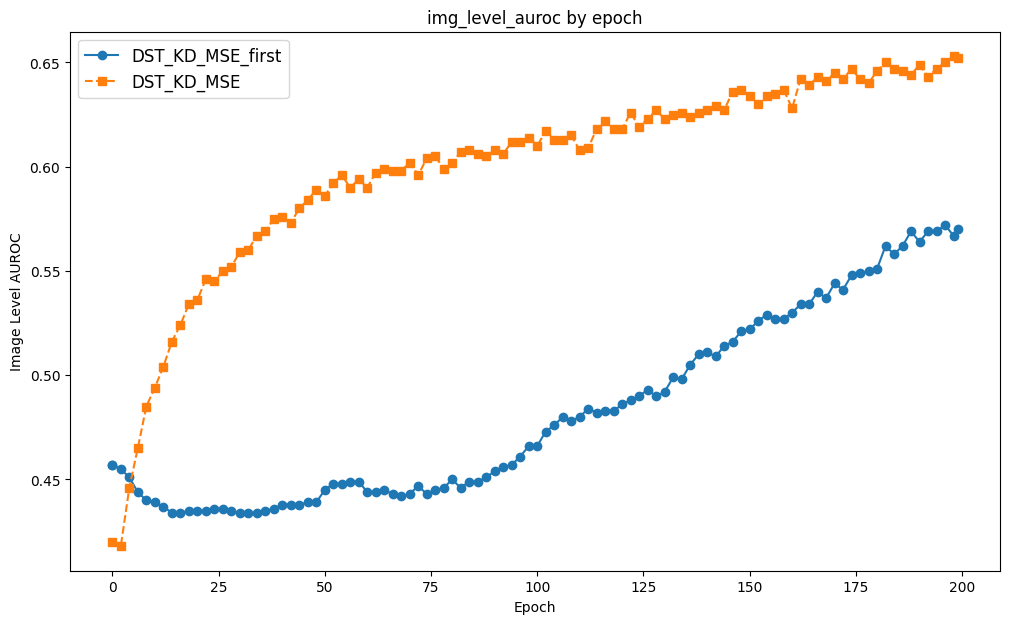

In [4]:
def get_class_results_and_task_order(cv):
    cv = os.path.join(cv, 'result_log.csv')
    df = pd.read_csv(cv)

    task_names = df['GT_class_name'].unique()

    class_results = pd.DataFrame()
    for i, tn in enumerate(task_names):
        if i == 0:
            temp_df = df[(df['class_name'] == tn) & (df['last'] == 1)].iloc[0:]
        else:
            temp_df = df[(df['class_name'] == tn) & (df['last'] == 1)].iloc[1:]
        temp_df = temp_df[['class_name', 'GT_class_name', 'img_level_auroc', 'pix_level_auroc', 'img_level_average_precision', 'pix_level_average_precision']]
        metrics = ['img_level_auroc', 'pix_level_auroc', 'img_level_average_precision', 'pix_level_average_precision']
        temp_df['average'] = temp_df[metrics].mean(axis=1)
        class_results = pd.concat([class_results, temp_df])
    
    class_results = class_results.round(3).reset_index(drop=True)
    class_results = class_results.loc[class_results.groupby(['class_name', 'GT_class_name'])['average'].idxmax()]

    return class_results

def get_class_results_dict(csv_dirs):
    class_results_dict = {}
    for cv in csv_dirs:
        class_results = get_class_results_and_task_order(cv)
        class_results_dict[cv.split('/')[-3].split('-')[0]] = class_results
    return class_results_dict

csv_dirs = [
            '/Volume/VAD/LifeLongerAD_cu121/results/CFGCAD/MVTecAD/test_DST-3_5_with_5_step-Continual_True-online_False/seed_42/results',            
            '/Volume/VAD/LifeLongerAD_cu121/results/CFGCAD/MVTecAD/sparse32_DST-3_5_with_5_step-Continual_True-online_False/seed_42/results'          
            ]


exp_name_mapping = {
    'test_capsule_DST': 'DST_KD_MSE_capsule',
    'test_toothbrush_DST': 'DST_KD_MSE_toothbrush',
    'test_screw_DST': 'DST_KD_MSE_screw',
    'sparse32_DST': 'DST_KD_MSE',
    'test_DST': 'DST_KD_MSE_first',
    'test_no': 'KD_MSE_first'
}


class_results_dict={}
for cv in csv_dirs:
    cv = os.path.join(cv, 'result_log.csv')
    df = pd.read_csv(cv)
    
    concat_df = df[(df['last']==0)].drop(columns=['task','last'])
    concat_df = concat_df.reset_index(drop=True)
    concat_df = concat_df.round(3)
    
    exp_name = cv.split('/')[-4].split('-')[0]
    
    # sparse32의 경우 특정 클래스만 필터링
    if exp_name == 'sparse32_DST':        
        concat_df = concat_df[concat_df['class_name'].isin(["['toothbrush', 'capsule', 'screw']"])]
        
    # exp_name_mapping 적용
    mapped_name = exp_name_mapping.get(exp_name, exp_name)
    class_results_dict[mapped_name] = concat_df
    
fig, axes = plt.subplots(1,1, figsize=(12, 7))

line_styles = ['-', '--', '-.']
markers = ['o', 's', '^']

for i, (key, data) in enumerate(class_results_dict.items()):
    linestyle = line_styles[i % len(line_styles)]
    marker = markers[i % len(markers)]
    
    axes.plot(data['epoch'], data['img_level_auroc'], 
             linestyle=linestyle, marker=marker, label=key)



axes.legend(fontsize=12)
axes.set_title('img_level_auroc by epoch')
axes.set_xlabel('Epoch')
axes.set_ylabel('Image Level AUROC')

plt.show()